In [1]:
import os
import numpy as np
import tensorflow as tf

# 读取Shakespeare文本文件
with open('shakespeare.txt', 'r', encoding='utf-8') as file:
    text = file.read()

# 显示文本的前500个字符
print(f"文本长度: {len(text)}")
print("文本预览:")
print(text[:500])
# 创建字符级别的字典
vocab = sorted(list(set(text)))
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for i, ch in enumerate(vocab)}

print(f"唯一字符数量: {len(vocab)}")
print("字符示例:", vocab[:20])
print("\n字符到索引映射示例:")
for char, idx in list(char_to_idx.items())[:5]:
    print(f"'{char}' -> {idx}")

# 创建字符到索引的映射
char_to_idx = {char: idx for idx, char in enumerate(vocab)}
idx_to_char = {idx: char for idx, char in enumerate(vocab)}

# 打印映射示例
print("\n字符到索引的映射示例:")
for char in text[:20]:
    print(f"'{char}' -> {char_to_idx[char]}")

# 将文本转换为数字序列
text_as_int = np.array([char_to_idx[c] for c in text]) #把全部文本都变为id
print(f"\n文本转换为数字序列的前20个元素:\n{text_as_int[:20]}")
print(f"将数字序列转回字符:\n{''.join([idx_to_char[idx] for idx in text_as_int[:20]])}")



文本长度: 1115394
文本预览:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor
唯一字符数量: 65
字符示例: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G']

字符到索引映射示例:
'
' -> 0
' ' -> 1
'!' -> 2
'$' -> 3
'&' -> 4

字符到索引的映射示例:
'F' -> 18
'i' -> 47
'r' -> 56
's' -> 57
't' -> 58
' ' -> 1
'C' -> 15
'i' -> 47
't' -> 58
'i' -> 47
'z' -> 64
'e' -> 43
'n' -> 52
':' -> 10
'
' -> 0
'B' -> 14
'e' -> 43
'f' -> 44
'o' -> 53
'r' -> 56

文本转换为数字序列的前20个元素:
[18 47 56 57 58  1 15 47 58 47 64 43 52 10  0 14 43 44 53 56]
将数字序列转回字符:


In [2]:

# 定义序列长度和批次大小
import torch
from torch.utils.data import Dataset, DataLoader

seq_length = 100  # 每个样本的序列长度
batch_size = 64   # 每个批次的样本数量

# 创建自定义数据集类
class ShakespeareDataset(Dataset):
    def __init__(self, text_as_int, seq_length):
        self.text_as_int = text_as_int  # 存储整数化的文本数据
        self.seq_length = seq_length    # 存储序列长度
        self.sub_len = seq_length + 1   # 一个样本的总长度（输入序列+目标字符）
        
    def __len__(self):
        # 计算可能的序列数量：总文本长度除以每个样本长度
        return len(self.text_as_int)//(self.seq_length+1)  # +1是因为要预测下一个字符
        
    def __getitem__(self, idx):
        # 根据索引获取一个样本序列
        # 将numpy数组转换为PyTorch长整型(Long)张量
        return torch.tensor(self.text_as_int[idx*self.sub_len:(idx+1)*self.sub_len], dtype=torch.long)

# 定义collate函数，用于处理批次数据
def collate_fct(batch):
    # 将批次数据堆叠成张量，确保类型为long
    batch = torch.stack(batch)  # 将列表中的张量堆叠成一个大张量
    # 输入序列是除了最后一个字符的所有字符
    input_batch = batch[:, :-1]  # 形状为[batch_size, seq_length]
    # 目标序列是除了第一个字符的所有字符（相当于输入序列向后移动一位）
    target_batch = batch[:, 1:]  # 形状为[batch_size, seq_length]
    return input_batch, target_batch

# 创建数据集实例
shakespeare_dataset = ShakespeareDataset(text_as_int, seq_length)

# 创建数据加载器
dataloader = DataLoader(
    shakespeare_dataset, 
    batch_size=batch_size,     # 每批次样本数
    shuffle=True,              # 随机打乱数据
    drop_last=True,            # 丢弃最后一个不完整的批次
    collate_fn=collate_fct     # 使用自定义的批次处理函数
)

# 打印示例，查看输入和目标
for input_batch, target_batch in dataloader:
    print(f"输入批次形状: {input_batch.shape}")  # 应该是[batch_size, seq_length]
    print(f"目标批次形状: {target_batch.shape}")  # 应该是[batch_size, seq_length]
    
    # 打印第一个样本的输入和目标
    print(input_batch)  # 打印输入批次的内容
    print(target_batch)  # 打印目标批次的内容
    break  # 只打印第一个批次

print(f"\n数据集大小: {len(shakespeare_dataset)}")  # 打印数据集中的样本总数
print(f"批次数量: {len(dataloader)}")  # 打印数据加载器中的批次总数


输入批次形状: torch.Size([64, 100])
目标批次形状: torch.Size([64, 100])
tensor([[53, 52,  1,  ..., 59,  1, 46],
        [43, 56, 52,  ..., 54,  6,  0],
        [ 8,  0,  0,  ..., 51, 43,  1],
        ...,
        [57, 59, 41,  ..., 57, 53, 51],
        [39, 60, 43,  ..., 52,  6,  1],
        [43,  1, 61,  ..., 31,  1, 27]])
tensor([[52,  1, 44,  ...,  1, 46, 39],
        [56, 52, 43,  ...,  6,  0, 21],
        [ 0,  0, 17,  ..., 43,  1, 59],
        ...,
        [59, 41, 46,  ..., 53, 51, 43],
        [60, 43,  1,  ...,  6,  1, 57],
        [ 1, 61, 43,  ...,  1, 27, 18]])

数据集大小: 11043
批次数量: 172


In [3]:
# 导入必要的库
import torch.nn as nn

# 定义RNN模型
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=1, dropout=0.5):
        super(SimpleRNN, self).__init__()
        # 词嵌入层，将字符索引转换为密集向量
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # RNN层
        self.rnn = nn.RNN(
            input_size=embedding_dim,     # 输入维度是嵌入维度
            hidden_size=hidden_dim,       # 隐藏状态维度
            num_layers=num_layers,        # RNN层数
            batch_first=True,             # 输入和输出张量的第一个维度是批次大小
            dropout=dropout if num_layers > 1 else 0  # 如果有多层，则在层之间应用dropout
        )
        
        # 输出层，将RNN的输出映射到词汇表大小
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x, hidden=None):
        # x形状: [batch_size, seq_length]
        batch_size = x.size(0)
        
        # 通过嵌入层
        x = self.embedding(x)  # 形状: [batch_size, seq_length, embedding_dim]
        
        # 通过RNN层
        output, hidden = self.rnn(x, hidden)
        # output形状: [batch_size, seq_length, hidden_dim]
        # hidden形状: [num_layers, batch_size, hidden_dim]
        
        # 通过全连接层
        output = self.fc(output)  # 形状: [batch_size, seq_length, vocab_size]
        
        return output, hidden
    
    def init_hidden(self, batch_size, device):
        # 初始化隐藏状态
        return torch.zeros(self.rnn.num_layers, batch_size, self.rnn.hidden_size).to(device)

# 设置模型参数
vocab_size = len(vocab)  # 词汇表大小
embedding_dim = 256      # 嵌入维度
hidden_dim = 1024         # 隐藏状态维度
num_layers = 2           # RNN层数
dropout = 0.5            # Dropout比率

# 实例化模型
model = SimpleRNN(vocab_size, embedding_dim, hidden_dim, num_layers, dropout)

# 打印模型结构
print(model)



SimpleRNN(
  (embedding): Embedding(65, 256)
  (rnn): RNN(256, 1024, num_layers=2, batch_first=True, dropout=0.5)
  (fc): Linear(in_features=1024, out_features=65, bias=True)
)


In [4]:
# 创建一个小批量数据来测试模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 定义批次大小和序列长度
batch_size = 32
seq_length = 100

# 创建随机输入数据
x = torch.randint(0, vocab_size, (batch_size, seq_length)).to(device)

# 初始化隐藏状态
hidden = model.init_hidden(batch_size, device)

# 前向传播
output, hidden = model(x, hidden)

# 打印输出形状
print(f"输入形状: {x.shape}")
print(f"输出形状: {output.shape}")
print(f"隐藏状态形状: {hidden.shape}")

# 验证输出维度是否正确
assert output.shape == (batch_size, seq_length, vocab_size), "输出形状不符合预期"
print("模型测试通过！")


输入形状: torch.Size([32, 100])
输出形状: torch.Size([32, 100, 65])
隐藏状态形状: torch.Size([2, 32, 1024])
模型测试通过！


In [5]:
from tqdm.auto import tqdm
# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 训练函数
def train_step(model, dataloader, optimizer, criterion, epochs=5):
    losses = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        # 使用tqdm创建进度条
        with tqdm(dataloader, desc=f"轮次 {epoch+1}/{epochs}") as pbar:
            for input_batch, target_batch in pbar:
                input_batch = input_batch.to(device)
                target_batch = target_batch.to(device)
                optimizer.zero_grad()
                
                # 前向传播
                output, _ = model(input_batch)
                
                # 计算损失
                # 重塑输出和目标以适应CrossEntropyLoss
                output = output.reshape(-1, vocab_size)
                target_batch = target_batch.reshape(-1)
                
                loss = criterion(output, target_batch)
                
                # 反向传播
                loss.backward()
                optimizer.step()
                
                current_loss = loss.item()
                epoch_loss += current_loss
                
                # 更新进度条显示的损失值
                pbar.set_postfix({"损失": f"{current_loss:.4f}"})
        
        # 计算并记录每个epoch的平均损失
        avg_epoch_loss = epoch_loss / len(dataloader)
        losses.append(avg_epoch_loss)
        print(f"轮次 {epoch+1}/{epochs} 完成, 平均损失: {avg_epoch_loss:.4f}")
    
    return losses

# 将模型移动到设备上
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 开始训练循环
losses = train_step(model, dataloader, optimizer, criterion, epochs=5)
  

轮次 1/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 1/5 完成, 平均损失: 2.1149


轮次 2/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 2/5 完成, 平均损失: 1.6807


轮次 3/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 3/5 完成, 平均损失: 1.5596


轮次 4/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 4/5 完成, 平均损失: 1.4968


轮次 5/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 5/5 完成, 平均损失: 1.4559


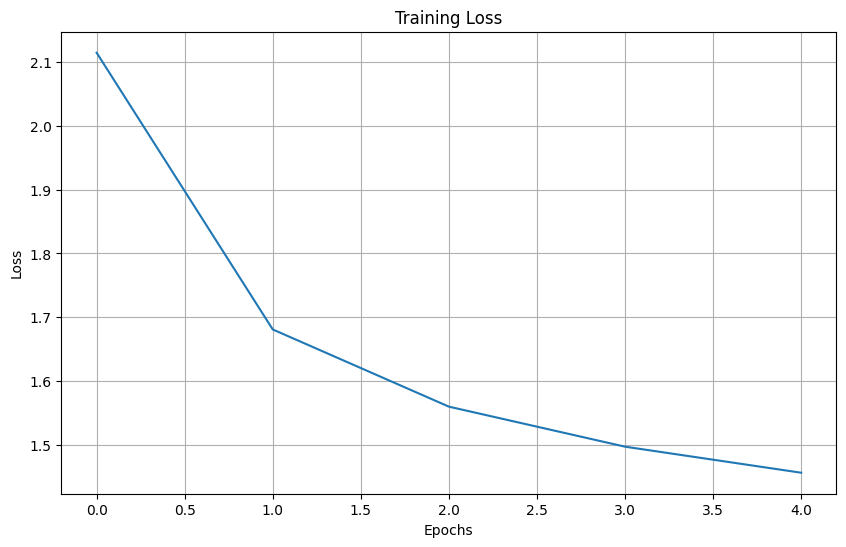

In [6]:
import matplotlib.pyplot as plt
# 绘制损失曲线
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

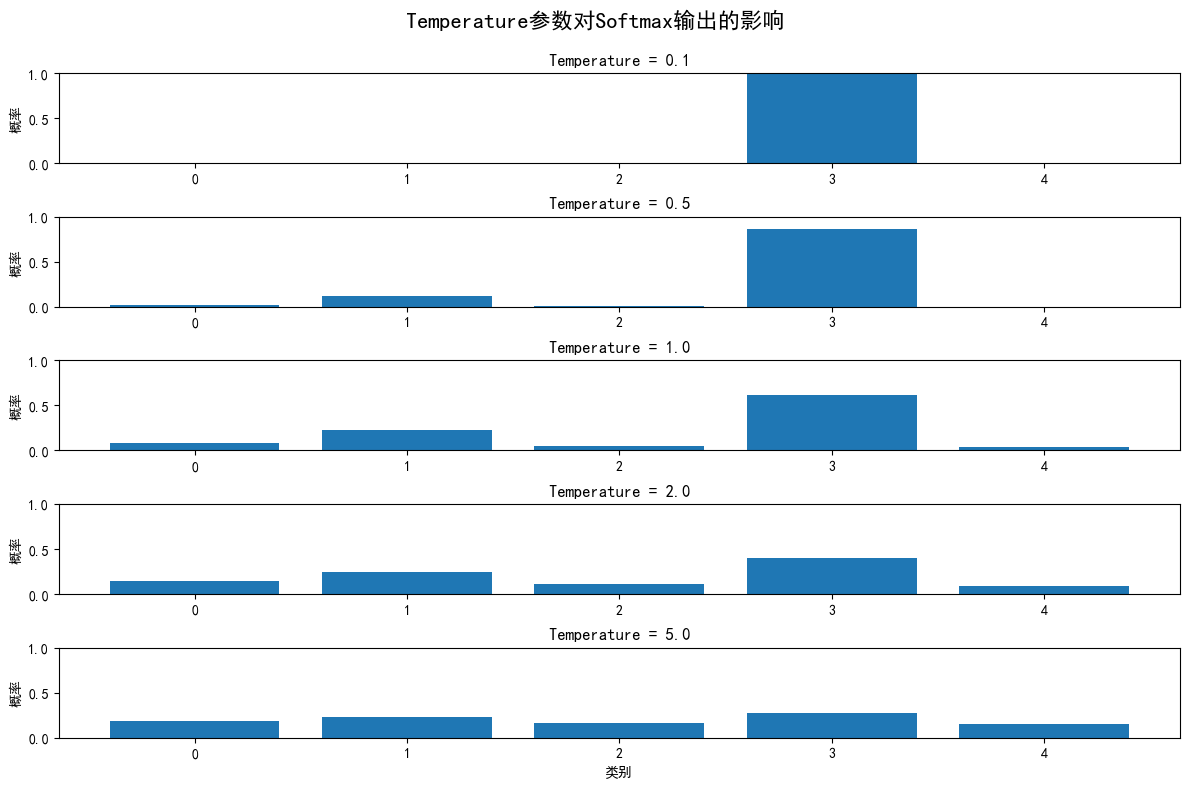

Temperature参数的影响:
- 低temperature (如0.1): 使概率分布更加尖锐，最高概率的类别被强化
- 高temperature (如5.0): 使概率分布更加平滑，各类别概率趋于均匀
- temperature=1.0: 标准softmax，不做额外缩放

在文本生成中，temperature控制生成文本的随机性/创造性:
- 低temperature: 生成更确定、更可预测的文本
- 高temperature: 生成更多样、更创新但可能不太连贯的文本


In [8]:
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 创建一个示例logits向量
logits = torch.tensor([1.0, 2.0, 0.5, 3.0, 0.1])

# 定义不同的temperature值
temperatures = [0.1, 0.5, 1.0, 2.0, 5.0]

plt.figure(figsize=(12, 8))

# 为每个temperature计算softmax并绘制
for i, temp in enumerate(temperatures):
    # 应用temperature缩放
    scaled_logits = logits / temp
    
    # 计算softmax
    probabilities = F.softmax(scaled_logits, dim=0).numpy()
    
    # 绘制概率分布
    plt.subplot(len(temperatures), 1, i+1)
    plt.bar(np.arange(len(logits)), probabilities)
    plt.ylim(0, 1)
    plt.title(f'Temperature = {temp}')
    plt.ylabel('概率')
    
    # 在最后一个子图上添加x轴标签
    if i == len(temperatures) - 1:
        plt.xlabel('类别')

plt.tight_layout()
plt.suptitle('Temperature参数对Softmax输出的影响', fontsize=16)
plt.subplots_adjust(top=0.9)
plt.show()

# 解释不同temperature的效果
print("Temperature参数的影响:")
print("- 低temperature (如0.1): 使概率分布更加尖锐，最高概率的类别被强化")
print("- 高temperature (如5.0): 使概率分布更加平滑，各类别概率趋于均匀")
print("- temperature=1.0: 标准softmax，不做额外缩放")
print("\n在文本生成中，temperature控制生成文本的随机性/创造性:")
print("- 低temperature: 生成更确定、更可预测的文本")
print("- 高temperature: 生成更多样、更创新但可能不太连贯的文本")


In [9]:
# 生成文本函数
def generate_text(model, start_string, char2idx, idx2char, num_generate=1000, temperature=1.0):
    """
    使用训练好的RNN模型生成文本
    
    参数:
        model: 训练好的RNN模型
        start_string: 生成文本的起始字符串
        char2idx: 字符到索引的映射字典
        idx2char: 索引到字符的映射字典
        num_generate: 要生成的字符数量，默认1000
        temperature: 控制采样随机性的温度参数，默认1.0
    
    返回:
        生成的文本字符串
    """
    # 将模型设置为评估模式（不计算梯度）
    model.eval()
    
    # 将起始字符串转换为索引序列
    input_indices = [char2idx[char] for char in start_string]
    # 将索引序列转换为张量，并添加批次维度，然后移至指定设备
    input_tensor = torch.tensor(input_indices, dtype=torch.long).unsqueeze(0).to(device) #unsqueeze(0) 在第0维上增加一个维度，形成[1, seq_len]的形状
    print(input_tensor.shape)  # 打印输入张量的形状，用于调试
    
    # 存储生成的文本，初始为起始字符串
    generated_text = start_string
    
    # 隐藏状态初始化为None，模型会在第一次前向传播时自动初始化
    hidden = None
    
    # 禁用梯度计算，提高推理速度并节省内存
    with torch.no_grad():
        # 循环生成指定数量的字符
        for _ in range(num_generate):
            # 获取模型预测输出和更新后的隐藏状态
            output, hidden = model(input_tensor, hidden)
            
            # 应用温度参数调整预测分布，temperature越低，分布越尖锐；越高，分布越平坦
            logits = output[:, -1, :] / temperature  # 只取序列中最后一个时间步的输出
            
            # 将logits转换为概率分布
            probabilities = F.softmax(logits, dim=-1)  # dim=-1表示在最后一个维度上应用softmax
            
            # 根据概率分布随机采样下一个字符的索引
            predicted_id = torch.multinomial(probabilities, 1) #从概率分布中采样一个元素，概率越大，被选中的可能性越大
            
            # 将预测的字符索引转换为实际字符并添加到生成文本中
            generated_char = idx2char[predicted_id.item()]  # item()将张量转换为Python标量
            generated_text += generated_char #放入到生成序列
            
            # 更新输入张量为当前预测的字符索引，用于下一次预测
            # 注意这里直接使用predicted_id作为新的输入，形状为[1, 1]
            input_tensor = predicted_id
    
    # 返回完整的生成文本
    return generated_text

# 调用函数生成文本，以'hello'为起始字符串
generate_text(model, 'hello', char_to_idx, idx_to_char)

torch.Size([1, 5])


"hellow? but he cannot, as I as jodding ampet about to say your state fall.\n\nPOMPEY:\nIn see out as I am temptry;\nTo one ow all my servilied at with the cetter.\nHow nome a sick-mool. With yourselves as your words;\nWhy, so I pray you, be neight hath tears thy holy show in death.\n\nROMEO:\nNow, as say i' the mile?\n\nPRINCE DINCE:\nO, the flatters is the blund, with the regreen to usman?\n\nMessenger:\n\nESCALUS:\nI am I speak;\nAlack.?\n\nShepherd, thou hast rought\nWhich he did o'er show this vallening yourself.\n\nANTONIO:\nClifford me to him; you shall strive to be likins to our play. Madam, sir, like himself and maid; and become worse!.\n\nWERWICK:\nNow I am a man done the imposery spirit;\nBut 'tis not the rich as dedign, yea can born.\n\nLEONTES:\nMy lord! after yet you better'd thither.\nAll but we shall over with us,\nShield them! let did I do\nI have living of this repented to have a ghomes,\nBut Veeple that noble advise. How reading a tormention forseech prevaid;\nTo to 